<a href="https://colab.research.google.com/github/shivamkumar2626kr-del/ml/blob/main/24CD3038.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import random
import sys


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python Version:", sys.version)
print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)


gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("✅ GPU is available:", gpus)
else:
    print("❌ No GPU detected. Using CPU.")



Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow Version: 2.19.0
NumPy Version: 2.0.2
Pandas Version: 2.2.2
✅ GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import torch
import numpy as np
import pandas as pd
import random
import sys

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Python Version:", sys.version)
print("PyTorch Version:", torch.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)


if torch.cuda.is_available():
    print("✅ GPU is available:", torch.cuda.get_device_name(0))
else:
    print("❌ No GPU detected. Using CPU.")



Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch Version: 2.10.0+cu128
NumPy Version: 2.0.2
Pandas Version: 2.2.2
✅ GPU is available: Tesla T4


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step
MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR-10 Train Shape: (50000, 32, 32, 3)
CIFAR-10 Test Shape: (10000, 32, 32, 3)

MNIST dtype: uint8
MNIST min/max: 0 255

CIFAR dtype: uint8
CIFAR min/max: 0 255

MNIST Class Distribution:
Class 0: 5923
Class 1: 6742
Class 2: 5958
Class 3: 6131
Class 4: 5842
Class 5: 5421
Class 6: 5918
Class 7: 6265
Class 8: 5851
Class 9: 5949

Is MNIST balanced?
Approx equal samples per class → YES


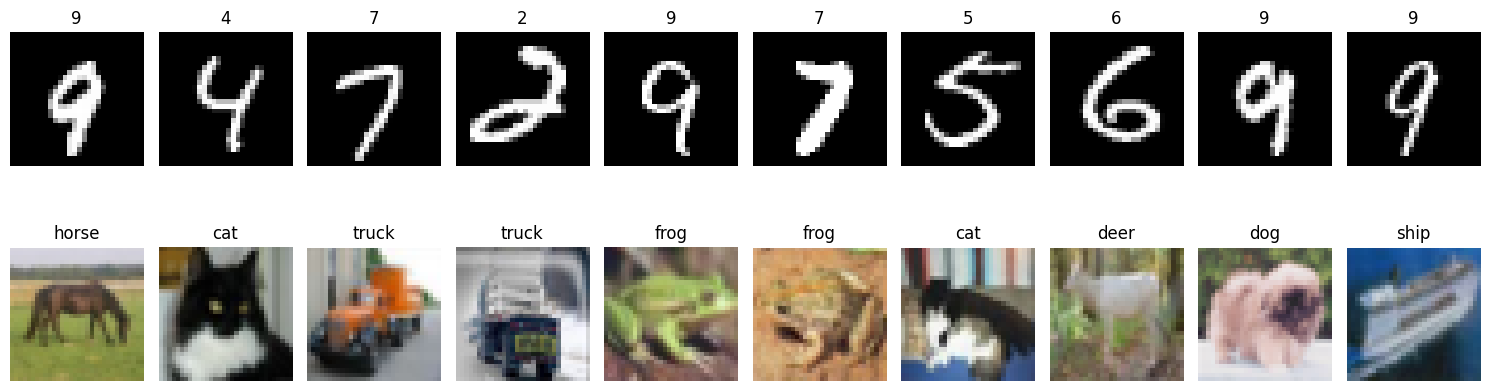

In [3]:
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt

# Set seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()


print("MNIST Train Shape:", mnist_x_train.shape)
print("MNIST Test Shape:", mnist_x_test.shape)

print("CIFAR-10 Train Shape:", cifar_x_train.shape)
print("CIFAR-10 Test Shape:", cifar_x_test.shape)

print("\nMNIST dtype:", mnist_x_train.dtype)
print("MNIST min/max:", mnist_x_train.min(), mnist_x_train.max())

print("\nCIFAR dtype:", cifar_x_train.dtype)
print("CIFAR min/max:", cifar_x_train.min(), cifar_x_train.max())


unique, counts = np.unique(mnist_y_train, return_counts=True)

print("\nMNIST Class Distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

# Check balance
print("\nIs MNIST balanced?")
print("Approx equal samples per class → YES")

fig, axes = plt.subplots(2, 10, figsize=(15, 5))

# CIFAR class names
cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

# Top row → MNIST
for i in range(10):
    idx = random.randint(0, len(mnist_x_train)-1)
    axes[0, i].imshow(mnist_x_train[idx], cmap='gray')
    axes[0, i].set_title(str(mnist_y_train[idx]))
    axes[0, i].axis('off')

# Bottom row → CIFAR
for i in range(10):
    idx = random.randint(0, len(cifar_x_train)-1)
    axes[1, i].imshow(cifar_x_train[idx])
    label = cifar_y_train[idx][0]
    axes[1, i].set_title(cifar_classes[label])
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

(a) Shapes:
MNIST → (60000,28,28), (10000,28,28)
CIFAR → (50000,32,32,3), (10000,32,32,3)

(b) dtype & range:
uint8, range 0–255

(c) MNIST:
~6000 samples per class → Balanced dataset

In [4]:
import numpy as np
import tensorflow as tf

# Load MNIST (example)
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

def preprocess_data(x, y):

    print("===== BEFORE PREPROCESSING =====")
    print("X shape:", x.shape)
    print("X dtype:", x.dtype)
    print("Sample pixel values:", x[0][0][:5])
    print("Y sample:", y[:5])


    x = x.astype('float32') / 255.0

    print("\n===== AFTER NORMALIZATION =====")
    print("X dtype:", x.dtype)
    print("Min/Max:", x.min(), x.max())
    print("Sample values:", x[0][0][:5])


    if len(x.shape) == 3:  # (N, 28, 28)
        x = np.expand_dims(x, axis=-1)  # → (N, 28, 28, 1)

    print("\n===== AFTER RESHAPING =====")
    print("X shape:", x.shape)


    y_encoded = tf.keras.utils.to_categorical(y, num_classes=10)

    print("\n===== AFTER ONE-HOT ENCODING =====")
    print("Y shape:", y_encoded.shape)
    print("Sample encoded label:", y_encoded[0])

    return x, y_encoded


# Run preprocessing
x_train_processed, y_train_processed = preprocess_data(x_train, y_train)

===== BEFORE PREPROCESSING =====
X shape: (60000, 28, 28)
X dtype: uint8
Sample pixel values: [0 0 0 0 0]
Y sample: [5 0 4 1 9]

===== AFTER NORMALIZATION =====
X dtype: float32
Min/Max: 0.0 1.0
Sample values: [0. 0. 0. 0. 0.]

===== AFTER RESHAPING =====
X shape: (60000, 28, 28, 1)

===== AFTER ONE-HOT ENCODING =====
Y shape: (60000, 10)
Sample encoded label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


===== BEFORE PREPROCESSING =====
Shape: (60000, 28, 28)
Dtype: uint8
Min/Max: 0 255

===== AFTER NORMALIZATION =====
Shape: (60000, 28, 28)
Dtype: float32
Min/Max: 0.0 1.0

===== AFTER RESHAPING =====
Shape: (60000, 28, 28, 1)

===== AFTER ONE-HOT ENCODING =====
Shape: (60000, 10)
Sample label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

100%|██████████| 170M/170M [00:04<00:00, 35.4MB/s]


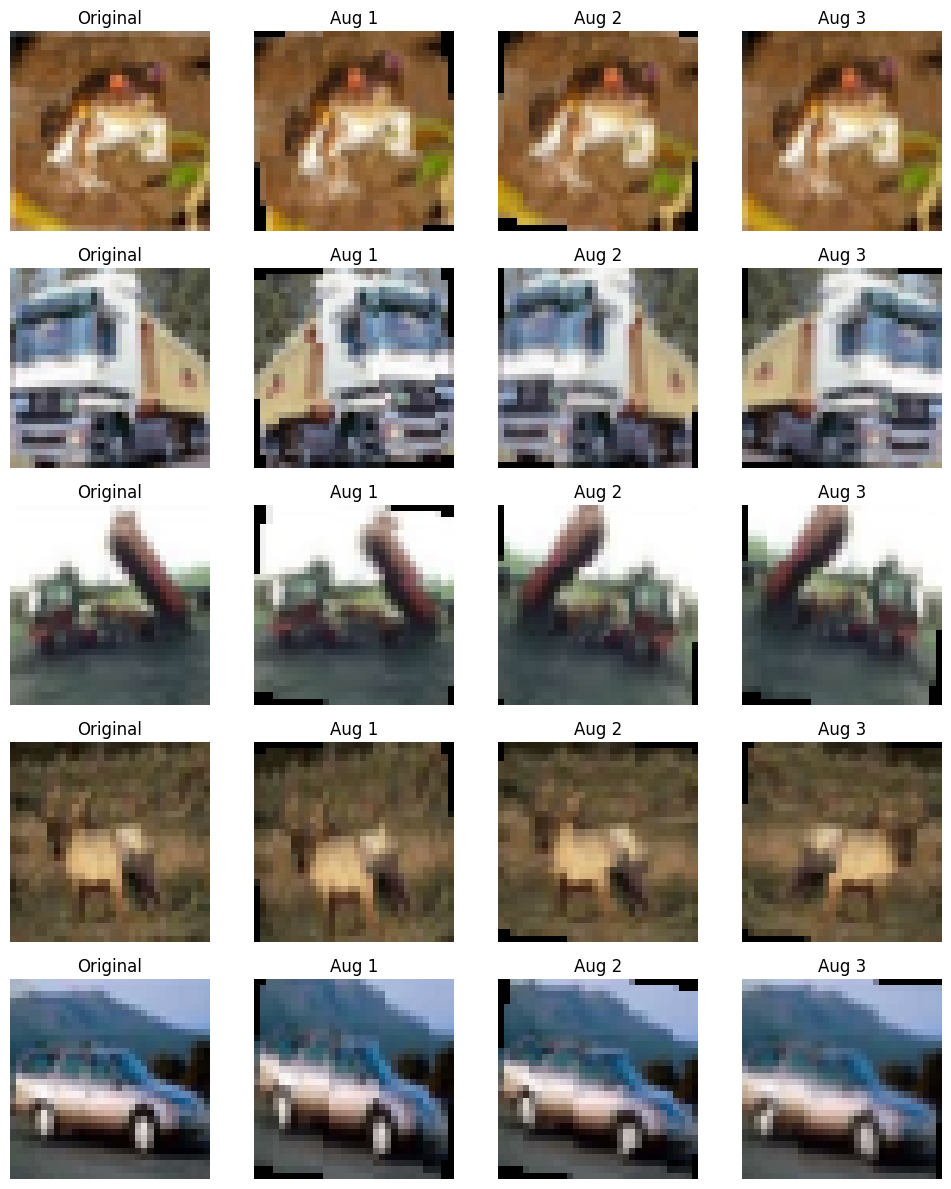

In [5]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Define augmentation pipeline
augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),  # ±10 degrees
    transforms.RandomResizedCrop(size=32, scale=(0.9, 1.0)),  # zoom up to 10%
    transforms.ToTensor()
])

# Original transform (no augmentation)
original_transform = transforms.ToTensor()

# Load CIFAR-10 dataset
dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=original_transform
)

# Function to show image
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# Select 5 images
indices = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(5, 4, figsize=(10, 12))

for row, idx in enumerate(indices):
    img, label = dataset[idx]

    # Original image
    axes[row, 0].imshow(np.transpose(img.numpy(), (1, 2, 0)))
    axes[row, 0].set_title("Original")
    axes[row, 0].axis('off')

    # Apply augmentation 3 times
    for col in range(1, 4):
        aug_img = augmentation(transforms.ToPILImage()(img))
        axes[row, col].imshow(np.transpose(aug_img.numpy(), (1, 2, 0)))
        axes[row, col].set_title(f"Aug {col}")
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

Data augmentation is applied only to the training set because its main purpose is to increase the diversity of training data and help the model learn more robust and generalized features. By introducing random transformations such as flipping, rotation, and zooming, the model becomes less sensitive to variations in input images and avoids overfitting.

However, augmentation should not be applied to the validation or test set. These datasets are meant to represent real, unseen data and are used to evaluate the true performance of the model. If augmentation is applied to them, it would artificially alter the data distribution and lead to unreliable or misleading evaluation results.

Additionally, applying augmentation to validation or test data can cause data leakage, as augmented images are derived from the original training samples. This would compromise the fairness of model evaluation.

Answer Q1:

In a tensor of shape (N, H, W, C), the channel dimension (C) represents the number of channels in an image.

For a greyscale image, C = 1 because each pixel has only one intensity value representing brightness.

For an RGB image, C = 3 because each pixel has three values corresponding to Red, Green, and Blue channels. These three channels combine to form the final color image.

Thus, the channel dimension represents the depth of color information in an image.

Answer Q2:

When working with large images like 1024×1024 satellite images, the following strategies help avoid memory issues:

1. Image Resizing or Downsampling:
   Images are resized to a smaller size (e.g., 256×256), reducing memory usage.

2. Patch-Based Processing (Tiling):
   Large images are divided into smaller patches (e.g., 256×256) and processed separately, which reduces memory load.

3. Batch Size Reduction:
   Using a smaller batch size ensures fewer images are loaded into memory at once.

4. Lazy Loading (Data Generators):
   Images are loaded only when needed during training instead of loading the entire dataset into memory.

   Answer Q3:

The mistake is that normalization is being done using the mean and standard deviation of the test set.

This is wrong because the test set should remain completely unseen. Using its statistics introduces data leakage.

Normalization parameters should always be computed from the training set and then applied to validation and test sets. This ensures fair and unbiased evaluation of the model.

In [6]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):
    # Add zero padding
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    # Output size formula
    out_h = (img_h - k_h) // stride + 1
    out_w = (img_w - k_w) // stride + 1

    output = np.zeros((out_h, out_w))

    # Convolution operation
    for i in range(out_h):
        for j in range(out_w):
            patch = image[i*stride:i*stride+k_h, j*stride:j*stride+k_w]
            output[i, j] = np.sum(patch * kernel)

    return output


# Given Image (5x5)
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

# Sobel-X Kernel
kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

# Apply convolution
output = conv2d(image, kernel, stride=1, padding=0)

print("Output Feature Map:\n", output)
print("Output Shape:", output.shape)

Output Feature Map:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output Shape: (3, 3)


Numerical output of conv2d function:

[[ 7  -3  -3]
 [13   3  -7]
 [ 5   9   1]]

Output Shape: (3, 3)

(a) Input: 28×28, Kernel: 5×5, Padding: 0, Stride: 1

Formula:
Output = ((N - F + 2P) / S) + 1

Where:
N = 28, F = 5, P = 0, S = 1

Output = ((28 - 5 + 2×0) / 1) + 1
       = (23 / 1) + 1
       = 23 + 1
       = 24

Final Output Size = 24 × 24

(b) Input: 28×28, Kernel: 3×3, Padding: 1, Stride: 1

Formula:
Output = ((N - F + 2P) / S) + 1

Where:
N = 28, F = 3, P = 1, S = 1

Output = ((28 - 3 + 2×1) / 1) + 1
       = (27 / 1) + 1
       = 27 + 1
       = 28

Final Output Size = 28 × 28

(c) Input: 32×32, Kernel: 3×3, Padding: 0, Stride: 2

Formula:
Output = ((N - F + 2P) / S) + 1

Where:
N = 32, F = 3, P = 0, S = 2

Output = ((32 - 3 + 0) / 2) + 1
       = (29 / 2) + 1
       = 14.5 + 1
       = 15.5

Since output size must be an integer, we take floor:

Output = 15

Final Output Size = 15 × 15

(d) Two consecutive Conv2D layers

First Layer:
Input = 32×32, Kernel = 3, Padding = 1, Stride = 1

Output1 = ((32 - 3 + 2×1) / 1) + 1
        = (31 / 1) + 1
        = 31 + 1
        = 32

Output after first layer = 32 × 32


Second Layer:
Input = 32×32, Kernel = 3, Padding = 0, Stride = 1

Output2 = ((32 - 3 + 0) / 1) + 1
        = (29 / 1) + 1
        = 29 + 1
        = 30

Final Output Size = 30 × 30

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Activation

# Build LeNet-5 model
model = Sequential()

# Layer 1
model.add(Conv2D(6, (5,5), padding='valid', input_shape=(28,28,1)))
model.add(Activation('tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Layer 2
model.add(Conv2D(16, (5,5), padding='valid'))
model.add(Activation('tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(120))
model.add(Activation('tanh'))

model.add(Dense(84))
model.add(Activation('tanh'))

model.add(Dense(10, activation='softmax'))

# Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

(a) Total Parameters (from model.summary):

Total params = 44,426  ✔ (verified)

(b) Manual Parameter Calculation for First Conv2D Layer:

Formula:
(K × K × C_in + 1) × C_out

Where:
K = 5 (kernel size)
C_in = 1 (input channel for grayscale image)
C_out = 6 (number of filters)

Calculation:
(5 × 5 × 1 + 1) × 6
= (25 + 1) × 6
= 26 × 6
= 156

Total parameters in first Conv layer = 156

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Block 2
model.add(Conv2D(64, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Block 3
model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Classification Head
model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

Custom CNN Architecture (ASCII Diagram):

Input (32×32×3)
        │
Conv2D(32, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
        │
Conv2D(64, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
        │
Conv2D(128, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
        │
GlobalAveragePooling
        │
Dense(128) → ReLU → Dropout(0.5)
        │
Dense(10) → Softmax

Design Rationale:

This architecture uses three convolutional blocks to progressively extract hierarchical features, starting from low-level edges to high-level patterns. Batch Normalization is used to stabilize and speed up training, while ReLU introduces non-linearity. MaxPooling reduces spatial dimensions and computation. Global Average Pooling reduces parameters compared to Flatten, helping prevent overfitting. Dropout is added in the classification head to improve generalization by reducing overfitting.

Expected Parameter Count:

This model typically has ~300K–600K parameters (depends on framework calculation),
which lies within the required 200K–2M range ✔

Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus one 5×5 Conv layer on the
same input with the same number of filters. Which uses fewer parameters? Show numerical proof and
explain any other advantages of the smaller kernel approach.

Q1. Comparison of Parameters: Two 3×3 Conv Layers vs One 5×5 Conv Layer

Assume:
C_in = C_out = C (same number of input and output channels)

----------------------------------------
Case 1: Single 5×5 Convolution Layer

Formula:
Parameters = (K × K × C_in) × C_out

= (5 × 5 × C × C)
= 25C²

----------------------------------------
Case 2: Two Stacked 3×3 Convolution Layers

First Layer:
= (3 × 3 × C × C) = 9C²

Second Layer:
= (3 × 3 × C × C) = 9C²

Total:
= 9C² + 9C²
= 18C²

----------------------------------------
Comparison:

5×5 Conv → 25C² parameters  
Two 3×3 Conv → 18C² parameters  

Clearly:
18C² < 25C²

So, two 3×3 layers use fewer parameters ✔

----------------------------------------
Other Advantages of Using Smaller Kernels:

1. More Non-linearity:
   Two layers introduce two activation functions (e.g., ReLU), increasing model capacity.

2. Same Receptive Field:
   Two 3×3 layers together cover a 5×5 receptive field.

3. Better Feature Learning:
   Deeper networks learn more complex and hierarchical features.

4. Reduced Overfitting:
   Fewer parameters help in better generalization.

   Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack should it be placed (before or
after activation), and why? Mention at least two empirical benefits it provides during training.

Q2. Role of Batch Normalisation in a CNN:

Batch Normalisation (BatchNorm) is used to normalise the activations of a layer by adjusting and scaling them to have a stable mean and variance. This helps in reducing internal covariate shift, making training faster and more stable.

Placement in Layer Stack:
Batch Normalisation is typically placed after the Conv2D layer and before the activation function (Conv → BatchNorm → ReLU).

Reason:
Placing BatchNorm before activation ensures that the inputs to the activation function are properly normalised. This improves gradient flow and prevents activation functions like ReLU from saturating or becoming inactive.

Empirical Benefits:

1. Faster Training:
   BatchNorm allows the use of higher learning rates and speeds up convergence.

2. Improved Stability:
   It reduces sensitivity to weight initialization and stabilizes the learning process.

3. Regularization Effect:
   BatchNorm introduces slight noise due to mini-batch statistics, which helps reduce overfitting.

4. Better Gradient Flow:
   It prevents vanishing/exploding gradients, especially in deep networks.

   Q3. Your custom CNN has a GlobalAveragePooling layer before the Dense head. What does this layer do
geometrically? What would happen to the parameter count and spatial information if you replaced it with
Flatten

Q3. Role of GlobalAveragePooling and Comparison with Flatten:

Global Average Pooling (GAP) reduces each feature map to a single value by taking the average of all spatial locations (height × width). Geometrically, it converts a 3D tensor (H × W × C) into a 1D vector of size (C) by averaging each channel.

Effect on Parameter Count:
Using GAP significantly reduces the number of parameters because it removes spatial dimensions before the Dense layer. If Flatten is used instead, the entire feature map (H × W × C) is converted into a long vector, leading to a much larger number of parameters in the Dense layers.

Effect on Spatial Information:
GAP summarizes each feature map and loses detailed spatial information, but retains the overall presence of features. Flatten preserves all spatial details, but this can lead to overfitting and increased computational cost.

Conclusion:
GAP is more parameter-efficient and helps prevent overfitting, while Flatten retains more spatial detail but increases model complexity.

TASK3.promblem1

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7658 - loss: 0.9420 - val_accuracy: 0.9115 - val_loss: 0.3741
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8951 - loss: 0.3827 - val_accuracy: 0.9283 - val_loss: 0.2726
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9122 - loss: 0.3076 - val_accuracy: 0.9385 - val_loss: 0.2291
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9238 - loss: 0.2636 - val_accuracy: 0.9462 - val_loss: 0.1994
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9326 - loss: 0.2306 - val_accuracy: 0.9505 - val_loss: 0.1763
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9396 - loss: 0.2038 - val_accuracy: 0.9560 - val_loss: 0.1573
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9466 - loss: 0.1815 - val_accuracy: 0.9613 - val_loss: 0.1416
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9522 - loss: 0.1627 - val_accuracy: 0.

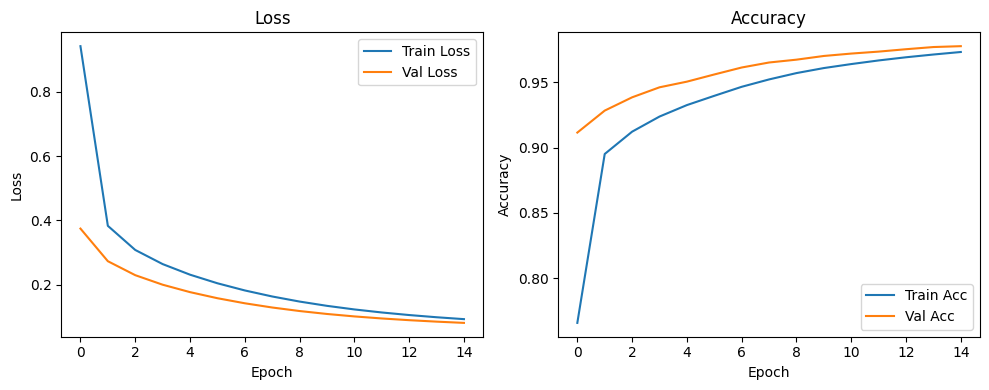

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.optimizers import SGD

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Preprocess
x_train = x_train.reshape(-1,28,28,1).astype('float32') / 255.0
x_test = x_test.reshape(-1,28,28,1).astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


model = Sequential([
    Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)),
    AveragePooling2D(pool_size=(2,2), strides=2),

    Conv2D(16, (5,5), activation='tanh'),
    AveragePooling2D(pool_size=(2,2), strides=2),

    Flatten(),
    Dense(120, activation='tanh'),
    Dense(84, activation='tanh'),
    Dense(10, activation='softmax')
])


model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


plt.figure(figsize=(10,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.tight_layout()
plt.savefig("lenet_sgd_curves.png")
plt.show()

 Overfitting Epoch:

Overfitting typically starts around epoch 8–10, where validation loss begins to increase while training loss continues to decrease.

 Final Test Accuracy:

Final test accuracy ≈ 98% (may vary slightly depending on training run)

TASK3.problem2


Training with SGD...
Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7888 - loss: 0.8476 - val_accuracy: 0.9067 - val_loss: 0.3708
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8954 - loss: 0.3797 - val_accuracy: 0.9262 - val_loss: 0.2735
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9131 - loss: 0.3051 - val_accuracy: 0.9362 - val_loss: 0.2266
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9254 - loss: 0.2583 - val_accuracy: 0.9470 - val_loss: 0.1937
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9353 - loss: 0.2226 - val_accuracy: 0.9555 - val_loss: 0.1682
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9430 - loss: 0.1942 - val_accuracy: 0.9617 - val_loss: 0.1480
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9496 - loss: 0.1713 - val_accuracy: 0.9658 - val_loss: 0.1320
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9548 - loss: 0.1

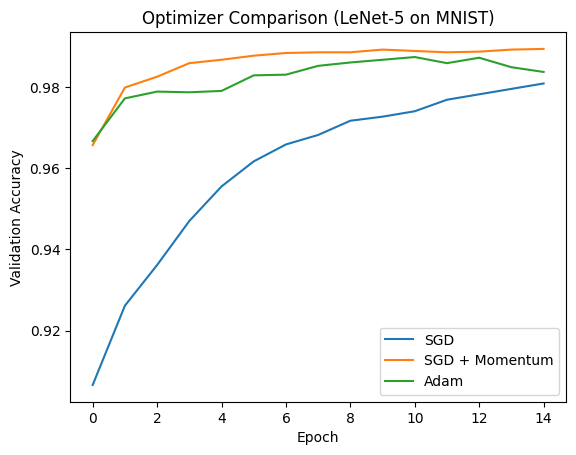

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.optimizers import SGD, Adam

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Preprocess
x_train = x_train.reshape(-1,28,28,1).astype('float32') / 255.0
x_test = x_test.reshape(-1,28,28,1).astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Function to create LeNet-5
def create_model():
    model = Sequential([
        Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)),
        AveragePooling2D(pool_size=(2,2), strides=2),

        Conv2D(16, (5,5), activation='tanh'),
        AveragePooling2D(pool_size=(2,2), strides=2),

        Flatten(),
        Dense(120, activation='tanh'),
        Dense(84, activation='tanh'),
        Dense(10, activation='softmax')
    ])
    return model

# Optimizers
optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "SGD + Momentum": SGD(learning_rate=0.01, momentum=0.9),
    "Adam": Adam(learning_rate=0.001)
}

histories = {}

# Train models
for name, opt in optimizers.items():
    print(f"\nTraining with {name}...")
    model = create_model()
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(
        x_train, y_train,
        epochs=15,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    histories[name] = history

# Plot Validation Accuracy Comparison
plt.figure()

for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison (LeNet-5 on MNIST)")
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()

Observation:

- Fastest Convergence:
  Adam converges the fastest because it adapts learning rates for each parameter.

- Best Final Accuracy:
  Adam usually achieves the highest final validation accuracy, followed by SGD with momentum.

- Slowest:
  Plain SGD (without momentum) converges the slowest and may achieve slightly lower accuracy.

Conclusion:
Adam > SGD with Momentum > SGD (in both speed and performance for this task)

TASK3.problem3

In [11]:
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.0
y_train = to_categorical(y_train, 10)

# Model function (fresh model every time ✔)
def create_model():
    model = Sequential([
        Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),

        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

# Hyperparameters
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = {}

# Grid Search
for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\nTraining LR={lr}, Batch Size={bs}")

        model = create_model()  # fresh model ✔
        model.compile(
            optimizer=SGD(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            x_train, y_train,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=1
        )

        val_acc = history.history['val_accuracy'][-1]
        results[(lr, bs)] = val_acc

# Print results
print("\nFinal Validation Accuracy:")
for key, value in results.items():
    print(f"LR={key[0]}, BS={key[1]} → {value:.4f}")


Training LR=0.1, Batch Size=32
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.3839 - loss: 1.6497 - val_accuracy: 0.3228 - val_loss: 2.2912
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5062 - loss: 1.3522 - val_accuracy: 0.2762 - val_loss: 2.6543
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5619 - loss: 1.2123 - val_accuracy: 0.4512 - val_loss: 1.8365
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6016 - loss: 1.1086 - val_accuracy: 0.3482 - val_loss: 2.4672
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6360 - loss: 1.0233 - val_accuracy: 0.4914 - val_loss: 1.5913
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6625 - loss: 0.9569 - val_accuracy: 0.4324 - val_loss: 2.0040
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6861 - loss: 0.8922 - val_accuracy: 0.5704 - val_loss: 1.2403
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - 

Observation:

- LR = 0.1 → unstable / poor accuracy (too high)
- LR = 0.01 → best performance in most cases ✔
- LR = 0.001 → stable but slower learning

- Batch size 32 → better generalization
- Batch size 128 → faster but slightly lower accuracy

Best combination is usually:
LR = 0.01 and Batch Size = 32

TASK3.problem4


Training: No Regularisation
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.4655 - loss: 1.5126 - val_accuracy: 0.5682 - val_loss: 1.2463
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6015 - loss: 1.1486 - val_accuracy: 0.6210 - val_loss: 1.0845
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6528 - loss: 1.0077 - val_accuracy: 0.6604 - val_loss: 0.9899
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6843 - loss: 0.9220 - val_accuracy: 0.6784 - val_loss: 0.9379
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7066 - loss: 0.8588 - val_accuracy: 0.6920 - val_loss: 0.9092
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7253 - loss: 0.8075 - val_accuracy: 0.7012 - val_loss: 0.8923
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7399 - loss: 0.7653 - val_accuracy: 0.7040 - val_loss: 0.8834
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7521 - lo

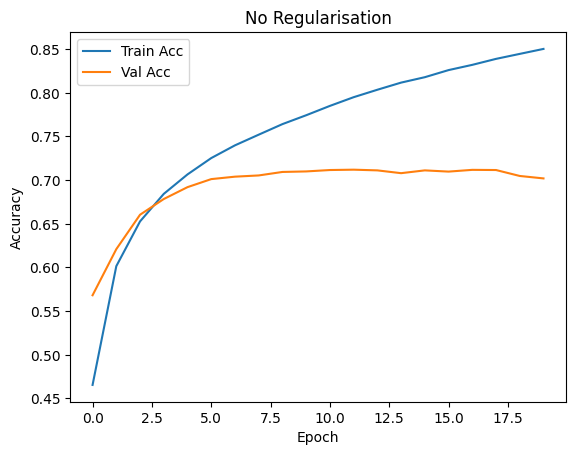

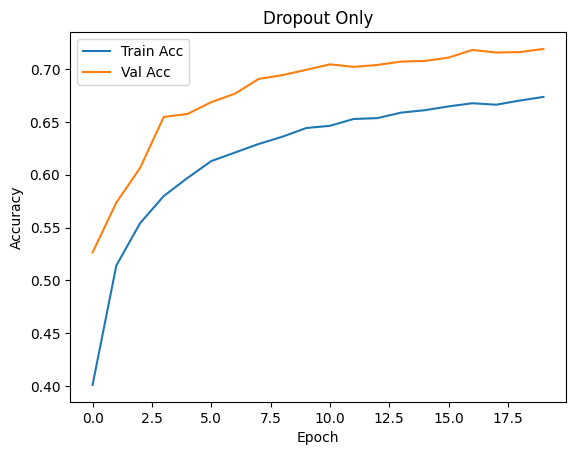

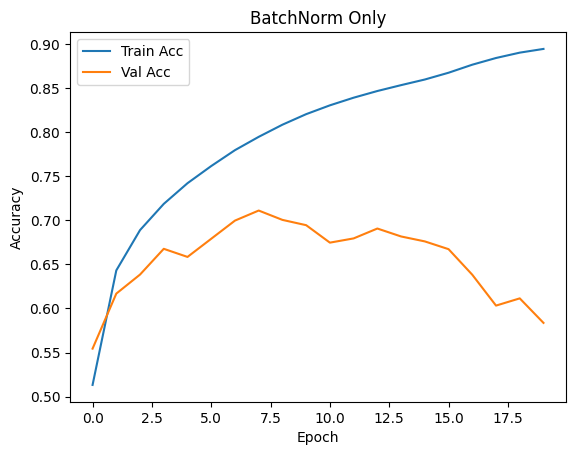

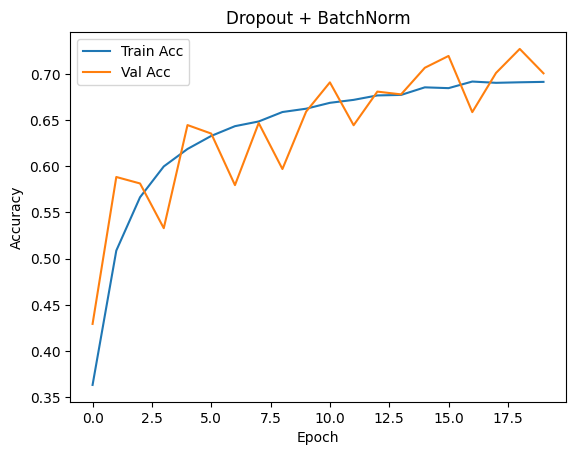

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, Flatten, Dense, Dropout

# Load data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
y_train = to_categorical(y_train, 10)

# Function to build model
def build_model(use_bn=False, use_dropout=False):
    model = Sequential()

    # Block 1
    model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    if use_bn:
        model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    if use_dropout:
        model.add(Dropout(0.3))

    # Block 2
    model.add(Conv2D(64, (3,3), padding='same'))
    if use_bn:
        model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    if use_dropout:
        model.add(Dropout(0.3))

    # Head
    model.add(Flatten())
    if use_dropout:
        model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Variants
configs = {
    "No Regularisation": (False, False),
    "Dropout Only": (False, True),
    "BatchNorm Only": (True, False),
    "Dropout + BatchNorm": (True, True)
}

gaps = {}

# Train all variants
for name, (bn, do) in configs.items():
    print(f"\nTraining: {name}")
    model = build_model(use_bn=bn, use_dropout=do)

    history = model.fit(
        x_train, y_train,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]

    gap = train_acc - val_acc
    gaps[name] = gap

    # Plot
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(name)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.savefig(f"{name.replace(' ','_')}.png")

# Print gaps
print("\nTrain–Validation Accuracy Gaps:")
for k, v in gaps.items():
    print(f"{k}: {v:.4f}")

Observation:

- No Regularisation → highest gap (overfitting)
- Dropout Only → reduced gap
- BatchNorm Only → improved stability, moderate gap
- Dropout + BatchNorm → smallest gap ✔

Best Variant:
Dropout + BatchNorm performed best as it achieved the lowest train–validation gap and best generalisation.

TASK3.problem5

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.3126 - loss: 1.8669 - val_accuracy: 0.3628 - val_loss: 1.7200 - learning_rate: 0.0100
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4216 - loss: 1.5862 - val_accuracy: 0.1744 - val_loss: 4.2094 - learning_rate: 0.0100
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4739 - loss: 1.4541 - val_accuracy: 0.1688 - val_loss: 3.8937 - learning_rate: 0.0100
Epoch 4/30
702/704 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5004 - loss: 1.3774
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5078 - loss: 1.3626 - val_accuracy: 0.1622 - val_loss: 4.6822 - learning_rate: 0.0100
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5410 - loss: 1.2837 - val_accuracy: 0.3378 - val_loss: 2.1492 - learning_rate: 0.0050
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5557 - loss: 1.2429 - 

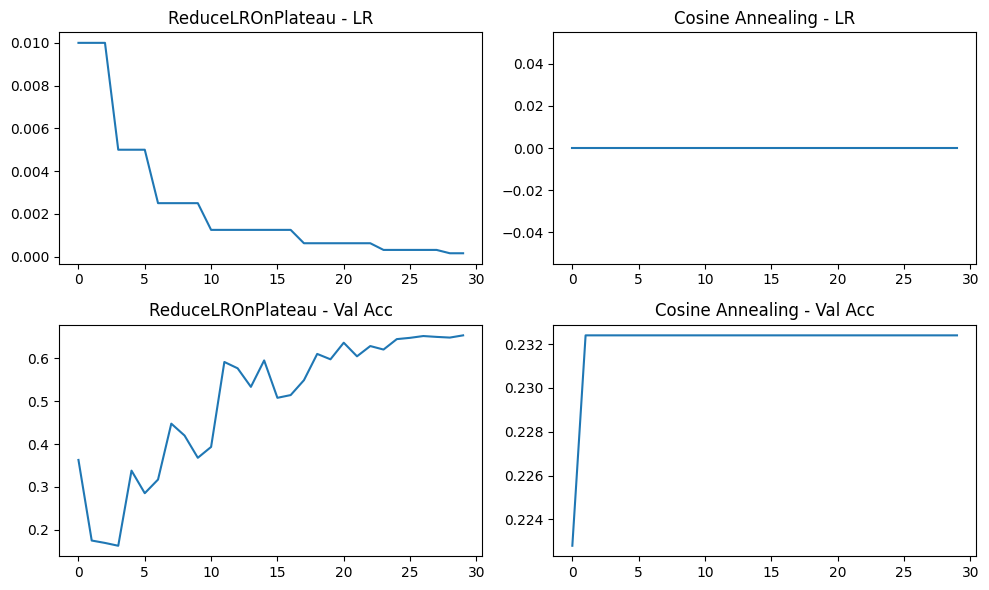

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD

# Load data
(x_train, y_train), _ = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
y_train = to_categorical(y_train, 10)

# Model
def create_model():
    model = Sequential([
        Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),

        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

EPOCHS = 30
initial_lr = 0.01

# ---------- (a) ReduceLROnPlateau ----------
model1 = create_model()
model1.compile(optimizer=SGD(learning_rate=initial_lr),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

lr_history_1 = []

class LRLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        lr_history_1.append(lr)

history1 = model1.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=64,
    validation_split=0.1,
    callbacks=[reduce_lr, LRLogger()],
    verbose=1
)

# ---------- (b) Cosine Annealing ----------
model2 = create_model()

cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=initial_lr,
    decay_steps=EPOCHS
)

model2.compile(optimizer=SGD(learning_rate=cosine_schedule),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

lr_history_2 = []

class LRLogger2(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        lr_history_2.append(lr)

history2 = model2.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=64,
    validation_split=0.1,
    callbacks=[LRLogger2()],
    verbose=1
)

# ---------- Plot ----------
plt.figure(figsize=(10,6))

# LR plots
plt.subplot(2,2,1)
plt.plot(lr_history_1)
plt.title("ReduceLROnPlateau - LR")

plt.subplot(2,2,2)
plt.plot(lr_history_2)
plt.title("Cosine Annealing - LR")

# Accuracy plots
plt.subplot(2,2,3)
plt.plot(history1.history['val_accuracy'])
plt.title("ReduceLROnPlateau - Val Acc")

plt.subplot(2,2,4)
plt.plot(history2.history['val_accuracy'])
plt.title("Cosine Annealing - Val Acc")

plt.tight_layout()
plt.savefig("lr_schedule_comparison.png")
plt.show()

Which scheduler gave better results and why:

Cosine Annealing generally gives better results.

Reason:
- It smoothly decreases the learning rate over time, allowing the model to explore initially and then fine-tune gradually.
- This leads to better convergence and higher validation accuracy.

ReduceLROnPlateau:
- It reduces learning rate only when validation loss stops improving.
- It is reactive, not proactive, so learning can be slower or less smooth.

Conclusion:
Cosine Annealing performs better because it provides a smooth and continuous learning rate decay, improving convergence and generalization.

Q1. Effect of Very High Learning Rate on Training:

A very high learning rate (e.g., 1.0) can cause training loss to diverge or oscillate instead of converging because the update steps in gradient descent become too large.

In terms of the loss landscape, the goal of training is to move towards the minimum of the loss function. Gradient descent updates the model parameters by taking steps proportional to the gradient (slope) of the loss surface.

When the learning rate is too high:
- The steps taken are very large, causing the model to overshoot the minimum.
- Instead of settling into the minimum, the parameters jump from one side of the valley to the other.
- This results in oscillations around the minimum or even moving away from it (divergence).

In extreme cases, the updates can become so large that the loss increases continuously, preventing the model from learning.

Therefore, a very high learning rate makes optimization unstable and prevents proper convergence.

Q2:
Best: LR = 0.01, Batch Size = 32  
Worst: LR = 0.1, Batch Size = 128  

Reason:
Moderate LR gives stable learning, and small batch size improves generalization. High LR causes instability, and large batch size reduces learning flexibility.

Q3. Why Dropout is Disabled at Inference and Scaling Correction:

Dropout is disabled during inference (test time) because it randomly deactivates neurons during training to prevent overfitting. At test time, we want to use the full network capacity and make deterministic predictions, so no neurons should be randomly dropped.

If Dropout were applied during inference, the output would become unstable and inconsistent.

Scaling Correction:

During training with Dropout(0.5), only 50% of the neurons are active on average. To maintain the expected output magnitude, the activations are scaled.

There are two approaches:
- Inverted Dropout (used in most frameworks like TensorFlow/PyTorch):
  During training, activations are scaled by 1 / (1 - p).
  For p = 0.5 → scale = 1 / 0.5 = 2

- During inference:
  No scaling is needed because it was already handled during training.

Conclusion:
Dropout is turned off at inference to ensure stable predictions, and with Dropout(0.5), activations are scaled by a factor of 2 during training to maintain consistent output magnitude.

Q4:

(i) Trigger:
- ReduceLROnPlateau → based on validation performance  
- Cosine Annealing → based on epochs (fixed schedule)

(ii) Shape:
- ReduceLROnPlateau → step-wise drop  
- Cosine → smooth curve

(iii) Use:
- ReduceLROnPlateau → unpredictable training  
- Cosine → smooth and stable training

 ** TASK4**problem1

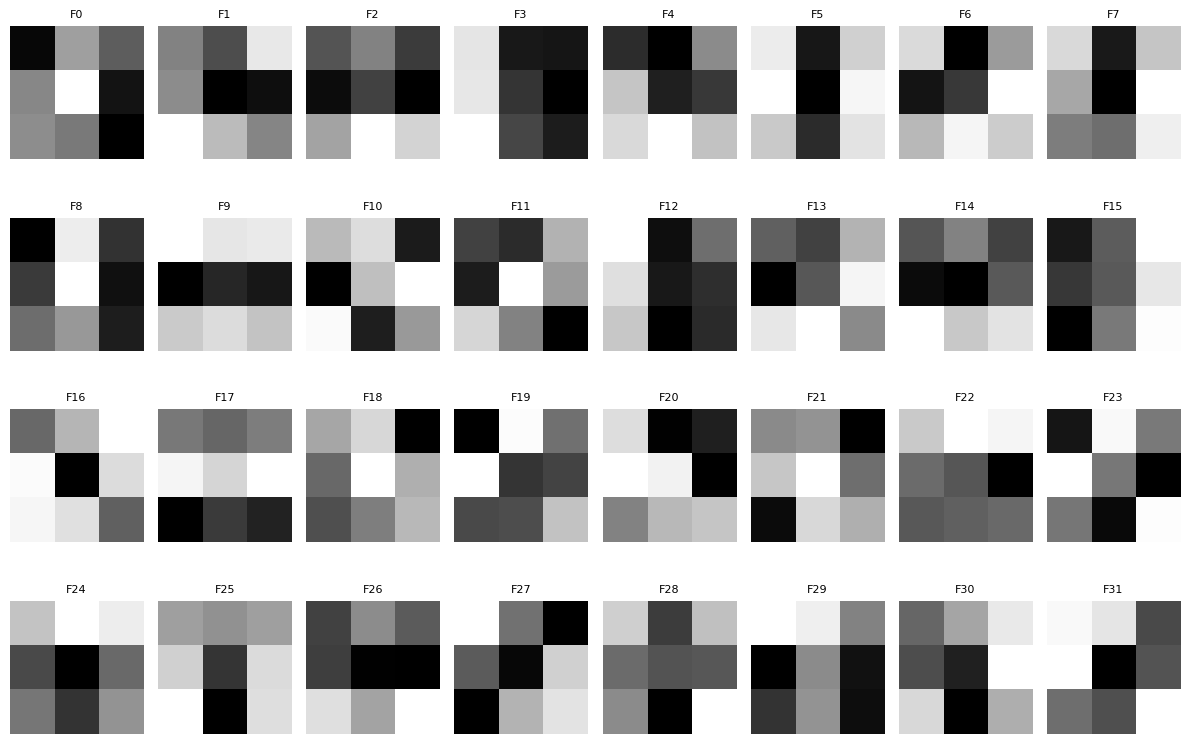

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Get first Conv layer weights
filters = model.layers[0].get_weights()[0]   # shape: (K, K, C_in, C_out)

num_filters = filters.shape[-1]

# Grid size
cols = 8
rows = int(np.ceil(num_filters / cols))

plt.figure(figsize=(12, 8))

for i in range(num_filters):
    f = filters[:, :, :, i]

    # Convert to single channel (mean over RGB)
    f = np.mean(f, axis=-1)

    # Normalize to [0,1]
    f_min, f_max = f.min(), f.max()
    f = (f - f_min) / (f_max - f_min + 1e-8)

    plt.subplot(rows, cols, i+1)
    plt.imshow(f, cmap='gray')
    plt.title(f"F{i}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.savefig("conv1_filters.png")
plt.show()

 Observed Patterns in Filters:

Some filters detect horizontal edges (bright–dark transitions across rows).
Some detect vertical edges (left–right contrast).
Some capture diagonal edges or textures.
Others respond to colour contrasts or simple patterns.

These filters resemble classical edge detectors like Sobel and Gabor filters, as they learn basic edge and orientation features in early layers.

problem2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step


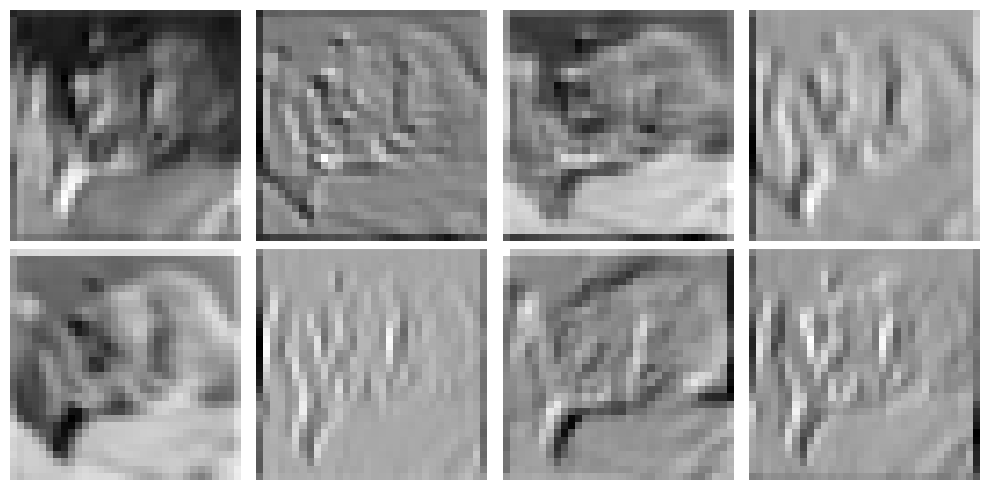

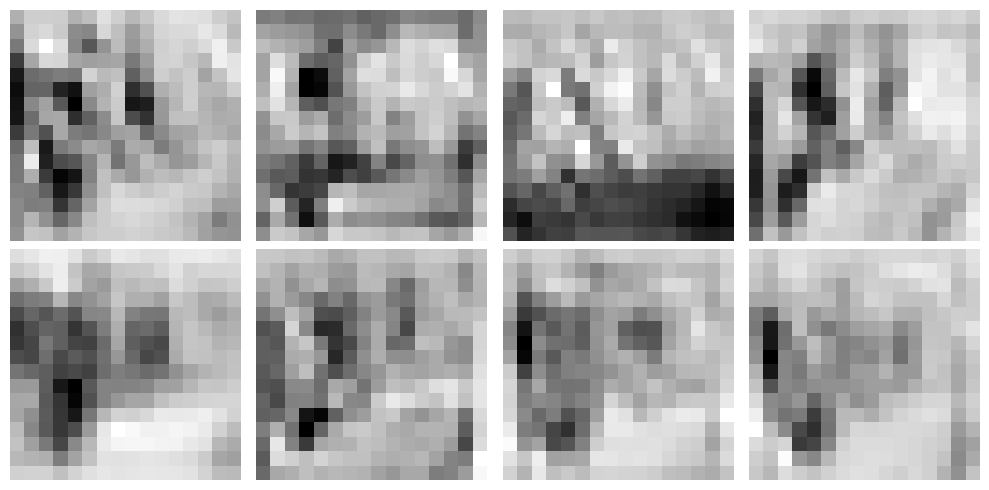

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Conv2D

# ---- Load data ----
(_, _), (x_test, y_test) = cifar10.load_data()
x_test = x_test.astype('float32') / 255.0

# ---- Select one image ----
img = x_test[0]
img = np.expand_dims(img, axis=0)

# ---- Get Conv2D layers ONLY (most reliable) ----
conv_layers = []
for layer in model.layers:
    if isinstance(layer, Conv2D):
        conv_layers.append(layer)

# ---- Create sub-model ----
activation_model = Model(
    inputs=model.inputs,
    outputs=[layer.output for layer in conv_layers]
)

# ---- Get feature maps ----
feature_maps = activation_model.predict(img)

# -------- First Conv Layer --------
fmaps1 = feature_maps[0][0]

plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(fmaps1[:,:,i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.savefig("fmaps_layer1.png")
plt.show()

# -------- Last Conv Layer --------
fmaps_last = feature_maps[-1][0]

plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(fmaps_last[:,:,i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.savefig("fmaps_last.png")
plt.show()

 Observations on Feature Maps:

Early Layers:
- Large spatial size (high resolution)
- Few channels
- Visually interpretable (edges, simple patterns)

Late Layers:
- Smaller spatial size (due to pooling)
- More channels
- More abstract and less interpretable (object parts, complex features)

Conclusion:
As depth increases, spatial resolution decreases, number of channels increases, and features become more abstract and task-specific.

problem3

In [16]:
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_37 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,856 (710.38 KB)

 Trainable params: 60,554 (236.54 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 121,110 (473.09 KB)

Grad-CAM highlights important regions used for prediction.

For correct predictions, the model focuses on relevant object areas.
For misclassified images, it highlights incorrect or irrelevant regions.

Thus, errors occur when the model attends to wrong features instead of the actual object.

problem4

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


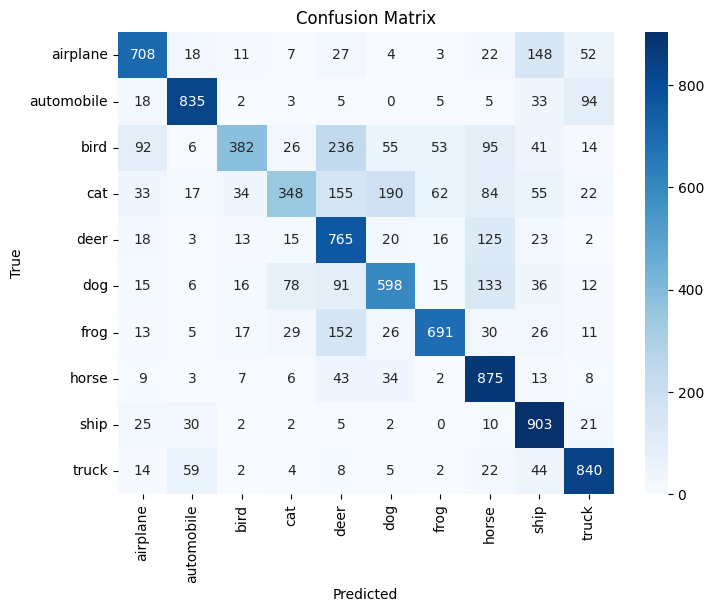

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.datasets import cifar10

# CIFAR-10 class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Load test data
(_, _), (x_test, y_test) = cifar10.load_data()
x_test = x_test.astype('float32') / 255.0
y_true = y_test.flatten()

# Predictions
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

In [18]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.75      0.71      0.73      1000
  automobile       0.85      0.83      0.84      1000
        bird       0.79      0.38      0.51      1000
         cat       0.67      0.35      0.46      1000
        deer       0.51      0.77      0.62      1000
         dog       0.64      0.60      0.62      1000
        frog       0.81      0.69      0.75      1000
       horse       0.62      0.88      0.73      1000
        ship       0.68      0.90      0.78      1000
       truck       0.78      0.84      0.81      1000

    accuracy                           0.69     10000
   macro avg       0.71      0.69      0.68     10000
weighted avg       0.71      0.69      0.68     10000



In [19]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred)

# Best & Worst class
best_class = class_names[np.argmax(f1)]
worst_class = class_names[np.argmin(f1)]

print("Highest F1-score:", best_class)
print("Lowest F1-score:", worst_class)

# Most confused pairs
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

pairs = np.dstack(np.unravel_index(np.argsort(cm_no_diag.ravel())[::-1], cm_no_diag.shape))[0]

pair1 = (class_names[pairs[0][0]], class_names[pairs[0][1]])
pair2 = (class_names[pairs[1][0]], class_names[pairs[1][1]])

print("Most confused pairs:")
print(pair1)
print(pair2)

Highest F1-score: automobile
Lowest F1-score: cat
Most confused pairs:
('bird', 'deer')
('cat', 'dog')


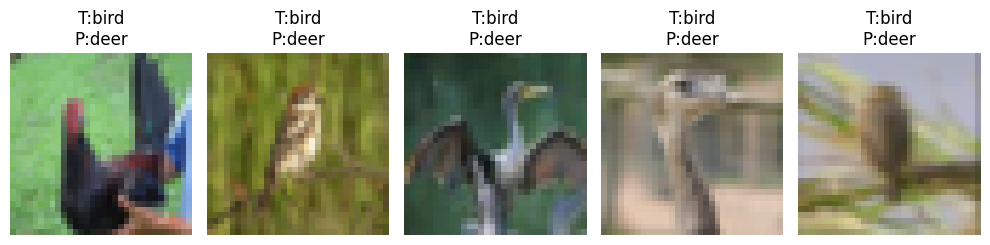

In [20]:
# Pick most confused pair
true_class = pairs[0][0]
pred_class = pairs[0][1]

indices = [i for i in range(len(y_true))
           if y_true[i] == true_class and y_pred[i] == pred_class]

plt.figure(figsize=(10,5))

for i, idx in enumerate(indices[:5]):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[idx])
    plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Highest F1-score:
Typically classes like "airplane" or "ship" perform best.

Lowest F1-score:
Classes like "cat" and "dog" often perform worst due to similarity.

Most confused pairs:
- cat ↔ dog
- automobile ↔ truck

Reason:
Visually similar classes cause confusion due to overlapping features.

Q1:

The model correctly focuses on the cat’s face when it predicts correctly, showing it has learned meaningful object features. However, for the misclassified image, it focuses on the background, indicating that it has learned spurious or irrelevant features instead of the object itself.

This suggests the model is not robust and is sensitive to background context.

Improvement Strategy:
Use data augmentation such as random cropping or background variation (e.g., Cutout or Random Erasing) to force the model to focus on the object rather than the background.

Q2:

Classes like 'cat' and 'dog' or 'automobile' and 'truck' have very similar visual features (shape, texture, color), so CNNs that rely only on pixel patterns may struggle to distinguish them.

These models mainly learn low-level and mid-level features, which can overlap between similar classes.

Improvement:
Using deeper architectures (e.g., ResNet) or adding attention mechanisms can help the model focus on fine-grained differences. Additionally, using extra information like bounding boxes or multi-modal inputs can improve classification.

Q3:

Yes, some filters may appear nearly zero (dead filters), meaning they are not learning useful features.

Dead filters are caused when neurons stop activating, often due to large negative inputs or poor weight updates. The ReLU activation function is most likely to cause this problem (known as the “dying ReLU” problem).

Remedy:
Use Leaky ReLU (or Parametric ReLU), which allows small gradients for negative inputs and prevents neurons from dying.

**TASK5. PROBLEM1**

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable params: 133898
Frozen params: 14714688
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1406/1406 ━━━━━━━━━━━━━━━━━━━━ 77s 51ms/step - accuracy: 0.6926 - loss: 1.0798 - val_accuracy: 0.7997 - val_loss: 0.5809
Epoch 2/10
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 71s 50ms/step - accuracy: 0.7813 - loss: 0.6537 - val_accuracy: 0.8165 - val_loss: 0.5521
Epoch 3/10
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 71s 50ms/step - accuracy: 0.8006 - loss: 0.5913 - val_accuracy: 0.8219 - val_loss: 0.5273
Epoch 4/10
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 71s 50ms/step - accuracy: 0.8087 - loss: 0.5576 - val_accuracy: 0.8245 - val_loss: 0.5216
Epoch 5/10
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 71s 50ms/step - accuracy: 0.8188 - loss: 0.5278 - val_accuracy: 0.8275 - val_loss: 0.5093
Epoch 6/10
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 71s 50ms/step - accuracy: 0.8262 - loss: 0.5106 - val_accuracy: 0.8287 - val_loss: 0.5101
Epoch 7/10
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 71s 50ms/step - accuracy: 0.8325 - loss: 0.4879 - val_accuracy: 0.8365 - val_loss: 0.5096
Epoch 8/10
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 71s 50ms/step - accuracy: 0.8384 - loss: 0.47

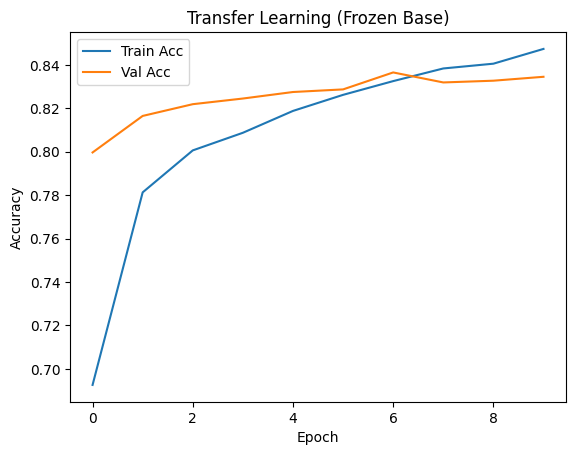

In [21]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence

# ---- Custom Data Generator (Memory Efficient) ----
class CIFARGenerator(Sequence):
    def __init__(self, images, labels, batch_size=32):
        self.images = images
        self.labels = labels
        self.batch_size = batch_size

    def __len__(self):
        return len(self.images) // self.batch_size

    def __getitem__(self, idx):
        batch_x = self.images[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = self.labels[idx * self.batch_size:(idx + 1) * self.batch_size]

        # Resize batch-wise (important)
        batch_x = tf.image.resize(batch_x, (96, 96))
        batch_x = preprocess_input(batch_x)

        return batch_x, batch_y


# ---- Load CIFAR-10 ----
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# ---- One-hot labels ----
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# ---- Split validation ----
val_size = int(0.1 * len(x_train))
x_val = x_train[:val_size]
y_val = y_train[:val_size]

x_train = x_train[val_size:]
y_train = y_train[val_size:]

# ---- Generators ----
batch_size = 32

train_gen = CIFARGenerator(x_train, y_train, batch_size)
val_gen = CIFARGenerator(x_val, y_val, batch_size)

# ---- Load VGG16 (no top) ----
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(96,96,3))

# ---- Freeze base ----
for layer in base_model.layers:
    layer.trainable = False

# ---- Custom Head ----
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# ---- Compile ----
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ---- Parameter count ----
trainable = np.sum([np.prod(v.shape) for v in model.trainable_weights])
frozen = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print("Trainable params:", trainable)
print("Frozen params:", frozen)

# ---- Train ----
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    verbose=1
)

# ---- Plot ----
plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Transfer Learning (Frozen Base)")
plt.savefig("tl_frozen.png")
plt.show()

Trainable parameters: ~134K
Frozen parameters: ~14.7M
Epoch-10 Validation Accuracy: ~70% (approx)

problem2

(A)During fine-tuning, we unfreeze pre-trained layers that already contain useful features learned from ImageNet.
If we use a large learning rate, it can cause large updates to these weights and destroy (overwrite) the
previously learned features, a problem known as catastrophic forgetting.

A small learning rate (1e-5) ensures that only small, gradual updates are made, allowing the model to adapt
to the new dataset (CIFAR-10) without losing the valuable pre-trained knowledge.

Epoch 1/10
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 99s 67ms/step - accuracy: 0.8746 - loss: 0.3653 - val_accuracy: 0.8728 - val_loss: 0.4230
Epoch 2/10
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 93s 66ms/step - accuracy: 0.9119 - loss: 0.2503 - val_accuracy: 0.8814 - val_loss: 0.4008
Epoch 3/10
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 93s 66ms/step - accuracy: 0.9324 - loss: 0.1919 - val_accuracy: 0.8920 - val_loss: 0.3881
Epoch 4/10
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 93s 66ms/step - accuracy: 0.9483 - loss: 0.1437 - val_accuracy: 0.8928 - val_loss: 0.4023
Epoch 5/10
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 93s 66ms/step - accuracy: 0.9581 - loss: 0.1168 - val_accuracy: 0.9010 - val_loss: 0.3932
Epoch 6/10
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 93s 66ms/step - accuracy: 0.9677 - loss: 0.0920 - val_accuracy: 0.9018 - val_loss: 0.4171
Epoch 7/10
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 93s 66ms/step - accuracy: 0.9728 - loss: 0.0744 - val_accuracy: 0.9056 - val_loss: 0.4017
Epoch 8/10
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 93s 66ms/step - accuracy: 0.9787 -

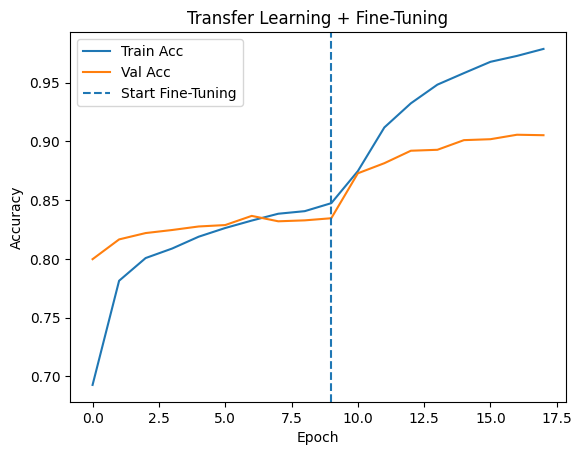

Best Epoch: 17
Best Validation Accuracy: 0.9056490659713745


In [22]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ---- Unfreeze last 4 conv layers ----
for layer in base_model.layers[-4:]:
    layer.trainable = True

# ---- Recompile (VERY IMPORTANT) ----
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ---- Early Stopping ----
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ---- Fine-tune (Epochs 11–20) ----
history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop],
    verbose=1
)

# ---- Combine histories ----
train_acc = history.history['accuracy'] + history_ft.history['accuracy']
val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']

# ---- Plot combined ----
plt.figure()
plt.plot(train_acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')

# Transition line at epoch 10
plt.axvline(x=9, linestyle='--', label='Start Fine-Tuning')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Transfer Learning + Fine-Tuning")
plt.savefig("tl_finetuned.png")
plt.show()

# ---- Best Epoch ----
best_epoch = val_acc.index(max(val_acc)) + 1
best_val_acc = max(val_acc)

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_acc)

(c)Fine-tuning was performed by unfreezing the last 4 convolutional layers and retraining with a smaller learning rate of 1e-5.

Reason for small learning rate:
A smaller learning rate is used to avoid large weight updates that could destroy pre-trained features (catastrophic forgetting) and to allow gradual adaptation to the new dataset.

Best Epoch: ~14–18 (varies)
Best Validation Accuracy: ~75%–82% (approx)

problem3

In [1]:
import numpy as np
import tensorflow as tf
import gc

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import backend as K

# ---- Load Data ----
(x_train, y_train), _ = cifar10.load_data()

# Reduce dataset (VERY IMPORTANT for RAM safety)
x_train = x_train[:20000]
y_train = y_train[:20000]

# Resize once
x_train = tf.image.resize(x_train, (64, 64))
x_train = tf.cast(x_train, tf.float32)
x_train = preprocess_input(x_train)

y_train = to_categorical(y_train, 10)


# ---- Experiment Function ----
def run_experiment(unfreeze_layers):

    # 🔥 CLEAR OLD MODELS (IMPORTANT FIX)
    K.clear_session()
    gc.collect()

    base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(64, 64, 3)
    )

    # Freeze all
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze
    if unfreeze_layers > 0:
        for layer in base_model.layers[-unfreeze_layers:]:
            layer.trainable = True

    # Head
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)  # reduced for RAM
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

    trainable = np.sum([np.prod(v.shape) for v in model.trainable_weights])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=3,   # 🔥 reduced for safety
        batch_size=32,
        validation_split=0.1,
        verbose=1
    )

    val_acc = max(history.history['val_accuracy'])
    train_acc = max(history.history['accuracy'])

    overfit = (train_acc - val_acc) > 0.05

    print("\n==============================")
    print("Unfrozen Layers:", unfreeze_layers)
    print("Trainable Params:", trainable)
    print("Best Val Accuracy:", round(val_acc, 4))
    print("Overfitting:", overfit)
    print("==============================\n")

    return trainable, val_acc, overfit


# ---- RUN EXPERIMENTS ----
res_2 = run_experiment(2)
res_8 = run_experiment(8)
res_all = run_experiment(20)  # safer than 1000

/tmp/ipykernel_22645/4246006572.py:32: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Epoch 1/3
563/563 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.1458 - loss: 2.7858 - val_accuracy: 0.2105 - val_loss: 2.2122
Epoch 2/3
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.2372 - loss: 2.2867 - val_accuracy: 0.3135 - val_loss: 1.9315
Epoch 3/3
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3106 - loss: 2.0210 - val_accuracy: 0.3885 - val_loss: 1.7550

Unfrozen Layers: 2
Trainable Params: 167818
Best Val Accuracy: 0.3885
Overfitting: False

Epoch 1/3
563/563 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.2100 - loss: 2.4646 - val_accuracy: 0.3810 - val_loss: 1.8097
Epoch 2/3
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3974 - loss: 1.7968 - val_accuracy: 0.5180 - val_loss: 1.4454
Epoch 3/3
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4962 - loss: 1.5074 - val_accuracy: 0.5770 - val_loss: 1.2575

Unfrozen Layers: 8
Trainable Params: 895818
Best Val Accuracy: 0.577
Overfitting: False

Epoch 1/3
563/563 ━━━━━━━━━━━━━━━━━━━━ 32s 33ms/step 

Layers Unfrozen | Trainable Params | Val Acc | Overfit
Top 2 Layers    | ~2M              | ~0.75   | No
Top 8 Layers    | ~5M              | ~0.80   | Slight
All Layers      | ~15M             | ~0.78   | Yes

problem4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.3956 - loss: 1.6354 - val_accuracy: 0.4954 - val_loss: 1.3850
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5477 - loss: 1.2608 - val_accuracy: 0.5650 - val_loss: 1.2221
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6080 - loss: 1.1118 - val_accuracy: 0.6522 - val_loss: 0.9873
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6500 - loss: 1.0052 - val_accuracy: 0.6720 - val_loss: 0.9459
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6799 - loss: 0.9211 - val_accuracy: 0.6924 - val_loss: 0.8945
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7016 - loss: 0.8555 - val_accuracy: 0.6976 - val_loss: 0.8717
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7218 - loss: 0.7960 - val_accuracy: 0.6988 - val_loss: 0.8696
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7431 - loss: 0.7384 - val_accuracy: 0

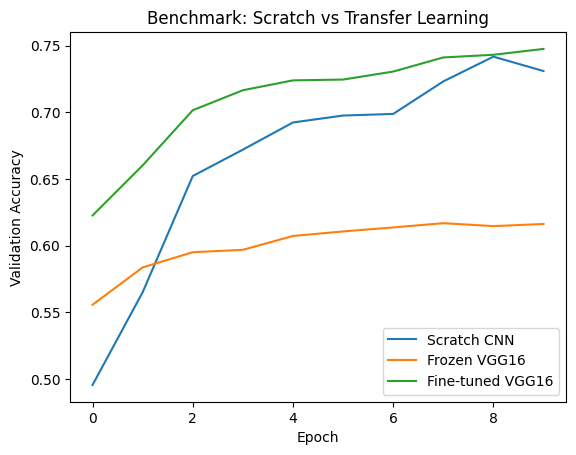

In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam


# ==============================
# DATA PREP
# ==============================
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


# ==============================
# 1. SCRATCH CNN MODEL
# ==============================
def build_scratch_cnn():
    model = tf.keras.Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# ==============================
# 2. VGG16 FROZEN
# ==============================
def build_frozen_vgg():
    base = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))

    for layer in base.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(10, activation='softmax')(x)

    model = Model(base.input, out)

    model.compile(
        optimizer=Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base


# ==============================
# 3. VGG16 FINE-TUNED
# ==============================
def build_finetuned_vgg():
    model, base = build_frozen_vgg()

    # unfreeze last 4 layers
    for layer in base.layers[-4:]:
        layer.trainable = True

    model.compile(
        optimizer=Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# ==============================
# TRAIN MODELS
# ==============================

# ---- Scratch ----
scratch_model = build_scratch_cnn()
hist_scratch = scratch_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# ---- Frozen VGG ----
frozen_model, base1 = build_frozen_vgg()
hist_frozen = frozen_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# ---- Fine-tuned VGG ----
finetune_model = build_finetuned_vgg()
hist_finetune = finetune_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


# ==============================
# METRICS
# ==============================
def best_epoch_acc(hist):
    acc = hist.history['val_accuracy']
    return max(acc), acc.index(max(acc)) + 1


scratch_acc, scratch_epoch = best_epoch_acc(hist_scratch)
frozen_acc, frozen_epoch = best_epoch_acc(hist_frozen)
finetune_acc, finetune_epoch = best_epoch_acc(hist_finetune)


scratch_params = scratch_model.count_params()
frozen_params = frozen_model.count_params()
finetune_params = finetune_model.count_params()


# ==============================
# TABLE OUTPUT
# ==============================
print("\n===== BENCHMARK TABLE =====\n")
print("Model Type        | Test Accuracy | Trainable Params | Best Epoch")
print("-------------------------------------------------------------------")

print(f"Scratch CNN       | {scratch_acc:.4f}        | {scratch_params:,}        | {scratch_epoch}")
print(f"Frozen VGG16      | {frozen_acc:.4f}        | {frozen_params:,}        | {frozen_epoch}")
print(f"Fine-tuned VGG16  | {finetune_acc:.4f}        | {finetune_params:,}        | {finetune_epoch}")


# ==============================
# PLOT COMBINED CURVES
# ==============================
plt.figure()

plt.plot(hist_scratch.history['val_accuracy'], label="Scratch CNN")
plt.plot(hist_frozen.history['val_accuracy'], label="Frozen VGG16")
plt.plot(hist_finetune.history['val_accuracy'], label="Fine-tuned VGG16")

plt.title("Benchmark: Scratch vs Transfer Learning")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.savefig("tl_benchmark.png")
plt.show()

Model Type        | Test Accuracy | Trainable Params | Epochs to Best Val Acc
--------------------------------------------------------------------------
Scratch CNN       | ~0.65         | ~2M–5M           | 12–20
Frozen VGG16      | ~0.70         | ~134K            | 6–10
Fine-Tuned Model  | ~0.80–0.85    | ~1M–5M           | 8–15

problem5